In [1]:
#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)


PID: 948829
CUDA_VISIBLE_DEVICES: None
hostname: e57e68c711d1
Failed to initialize NVML: Unknown Error



In [2]:

#MOANA ONLY
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [1]:
# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    _linux_candidates = [Path("/knuckles_drive"), Path("/workspaces/MScPROJECT_LOCAL")]
    for _candidate in _linux_candidates:
        if _candidate.exists():
            project_root = _candidate
            break
    else:
        from A_Config import REPO_ROOT
        project_root = Path(REPO_ROOT)  # robust fallback -- REPO_ROOT is computed from A_Config.py's own location, so it's correct on any machine/mount
load_dotenv(project_root / ".env")
case_name = "201_copper_01"
#experiment = "cat_03_agent_temp"
experiment = None
Question = "were the police justified in shooting the man they arrested?"
if experiment:
    asset_name = f"{case_name}_{experiment}"
else: 
    asset_name = case_name
from A_Config import (
    set_case, case_dir, source_dir, query_dir, yolo_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, cut3r_output_dir, ply_dir, reg_dir,
    csv_path_gps, csv_path_pose, FRAME_NAME_FMT,
)
set_case(case_name, experiment)

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir().glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

Case    : 201_copper_01
Video   : log_1081378_body-cam_v1.mp4


In [2]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": True,
    "FRAME_SELECTION": False,
    "RECON_CAM_POSES": False,
    "RECON_3D": False,
    "CUT3R_RECON": False,
    "MEGA_SAM_RECON": False,
    "VGGT_RECON": False,
    "VGGT_O_RECON": False,
    "MULTI_PART_RECON": False,
    "GOOGLE_MAP": False,
    "PROJECTION_MAP": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : True,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False
}
MENU_KEYS = {"RECON_CAM_POSES", "RECON_3D", "CUT3R_RECON", "MEGA_SAM_RECON",
             "VGGT_RECON", "VGGT_O_RECON", "MULTI_PART_RECON",
             "GOOGLE_MAP", "PROJECTION_MAP", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

In [5]:
#turn a video into a text description
if flags["VID_TO_TEXT"] == True:
    from Two2D.A_gemini import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())
else:
    print("Cell disabled")



KeyboardInterrupt: 

In [ ]:
#Get key things to examine
if flags["VID_TO_TEXT"] ==True:
    #Query to text to get rough frame ranges. 
    from Two2D.A_gemini import query_from_description
    human_out, detections = query_from_description(
        Question ,
        query_dir() / f"{case_name}_description.txt" , 
        query_dir() / f"{case_name}_objects.txt",
        case_dir()
        
    )
    print(detections)
else:
    print("Cell disabled")

The suspect's weapon (initially perceived as a real handgun but later identified as a BB gun) is highly relevant to determining whether the shooting was justified. The officers had to make a split-second decision based on the appearance of the weapon in the suspect's hand, making its visual details and how the suspect held it central to the justification analysis.

The yellow taser is also relevant as it represents the less-lethal force option deployed by the officers during the encounter, showing their immediate escalation of force and attempt to subdue the suspect before or during the deployment of the firearm.


[{'subject': 'weapon', 'start_s': 147, 'end_s': 155}, {'subject': 'weapon', 'start_s': 190, 'end_s': 204}, {'subject': 'weapon', 'start_s': 225, 'end_s': 237}, {'subject': 'taser', 'start_s': 144, 'end_s': 161}, {'subject': 'taser', 'start_s': 266, 'end_s': 300}, {'subject': 'taser', 'start_s': 341, 'end_s': 361}]


In [ ]:
#subject sselector
if flags["VID_TO_TEXT"] ==True:
        
    from A_Interactions import subject_selector
    subject_frame_range = subject_selector(
        video_path,
        detections,
        conf= 0.05,
        ) 
    print(subject_frame_range)
else:
    print("Cell disabled")

'weapon' not on list — no matching YOLO class, skipping detection 1.
'weapon' not on list — no matching YOLO class, skipping detection 2.
'weapon' not on list — no matching YOLO class, skipping detection 3.
'taser' not on list — no matching YOLO class, skipping detection 4.
'taser' not on list — no matching YOLO class, skipping detection 5.
'taser' not on list — no matching YOLO class, skipping detection 6.
No preview frames could be extracted.
None


In [ ]:
#YOLO - track moving subject footage
#works from video
from A_YOLO_seg import track_subject_masks_from_hints
if flags["TRACKING"] == True:
    import sys
    sys.path.insert(0, str(project_root / "src"))

    from A_YOLO_seg import track_subject_masks

    results = track_subject_masks_from_hints(
        video_path=video_path,
        output_dir=str(yolo_masks_dir()),
        detections=subject_frame_range,
        miss_threshold=100,
        conf=0.05
        )

    print(f"\n{len(results)} masks written to {yolo_masks_dir()}")
    print(results)
else:
    print("Cell disabled")


ModuleNotFoundError: No module named 'A_YOLO_seg'

In [ ]:
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path, yolo_masks_dir(),api_key)

GPS_signal: yes
Subject_frames_present: [3854, 3855, 3856, 3858, 3859, 3860, 3861, 3863, 3864, 3865, 3866, 3867, 3868, 3869, 3871, 3872, 3873, 3874, 3875, 3876, 3877, 3878, 3879, 3880, 3881, 3882, 3883, 3884, 3886, 3887, 3888, 3889, 3890, 3891, 3892, 3893, 3894, 3895, 3896, 3897, 3898, 3899, 3911, 3912, 3914, 3915, 3916, 3918, 3919, 3920, 3921, 3924, 3925, 3926, 3927, 3931, 3933, 3934, 3935, 3936, 3937, 3939, 3941, 3942, 3943, 3944, 3945, 3946, 3948, 3950, 3951, 3954, 3955, 3956, 3957, 3958, 3959, 3961, 3962, 3963, 3964, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974, 3975, 3976, 3977, 3978, 3979, 3980, 3981, 3982, 3983, 3984, 3985, 3986, 3987, 3988, 3989, 3990, 3991, 3992, 3993, 3994, 3995, 3996, 3997, 3998, 3999, 4000, 4001, 4002, 4003, 4004, 4005, 4006, 4007, 4008, 4009, 4010, 4011, 4012, 4013, 4014, 4015, 4016, 4017, 4018, 4019, 4021, 4022, 4023, 4024, 4025, 4026, 4027, 4029, 4030, 4031, 4032, 4033, 4034, 4035, 4036, 4037, 4038, 4039, 4040, 4041, 4042, 4043, 4044, 4048, 4049,

PRODUCER IS ACTIVE FROM HERE

In [ ]:
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from producer_agent_execution import run_producer_agent, build_producer_prompt_draft1
analysis_2d_for_decisions=[]
prompt = build_producer_prompt_draft1(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt, mode ="draft")


[18:59:19 +  0.00s] run_producer_agent: start
[18:59:19 +  0.00s] thread: start
[18:59:19 +  0.00s] event loop: created
[18:59:19 +  0.01s] query: start


Ignoring 4 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspaces/knuckles_drive"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspaces/knuckles_drive"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


[18:59:41 + 21.63s] turn 1 usage (claude-sonnet-5): in=2 out=2 cache_write=0 cache_read=16484
[19:00:10 + 50.68s] turn 2 usage (claude-sonnet-5): in=2 out=2 cache_write=0 cache_read=16484
[19:00:10 + 50.68s] tool call: Write (/workspaces/knuckles_drive/Data/201_copper_01/012_agent_p_output/201_copper_01_paper_edit_draft.json)
[19:00:12 + 52.80s] turn 3 usage (claude-sonnet-5): in=2 out=1 cache_write=4773 cache_read=16484
[19:00:13 + 53.03s] turn 4 usage (claude-sonnet-5): in=2 out=1 cache_write=4773 cache_read=16484
[19:00:13 + 53.03s] tool call: Glob (Data/201_copper_01/012_agent_p_output/*)
[19:00:23 + 63.23s] turn 5 usage (claude-sonnet-5): in=2 out=40 cache_write=157 cache_read=21257
[19:00:23 + 63.23s] tool call: Read (/workspaces/knuckles_drive/Data/201_copper_01/012_agent_p_output/201_copper_01_paper_edit_draft.json)
[19:00:24 + 64.97s] turn 6 usage (claude-sonnet-5): in=2 out=1 cache_write=2725 cache_read=21414
[19:00:52 + 92.88s] turn 7 usage (claude-sonnet-5): in=2 out=1 cach

In [6]:
# Re-run this cell on its own to regenerate the HTML/flags after editing
# render_paper_edit.py — no agent call, no cost. importlib.reload is needed
# because the module was already imported once this kernel session; without
# it, edits to the file wouldn't be picked up until a kernel restart.
import importlib
import json
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
import render_paper_edit
importlib.reload(render_paper_edit)

from render_paper_edit import render_and_save, derive_and_save_flags

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(paper_edit_json_path, producer_flags.keys())
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))


=== Rendered HTML ===
  /workspaces/knuckles_drive/Data/201_copper_01/012_agent_p_output/201_copper_01_paper_edit.html

=== Derived flags (from 201_copper_01_flags.json) ===
{
  "RECON_CAM_POSES": false,
  "RECON_3D": false,
  "CUT3R_RECON": false,
  "MEGA_SAM_RECON": false,
  "VGGT_RECON": false,
  "VGGT_O_RECON": false,
  "MULTI_PART_RECON": false,
  "GOOGLE_MAP": false,
  "PROJECTION_MAP": false,
  "MASK_OVERLAYS": false,
  "MULTICAM": false
}


In [ ]:
#START AND END CALCULATORS
print(min(analysis['Subject_frames_present']))
print(max(analysis['Subject_frames_present']))

best_idx = analysis['best_seq_idx']
start_3D_recon = analysis['continuous frame sequences'][best_idx][0]
end_3D_recon = analysis['continuous frame sequences'][-1][1]      

print("start 3d", start_3D_recon)
print("end 3d" ,end_3D_recon)

start_cam_recon = max(start_3D_recon-2200, 0) # this needs to be made batter!
end_cam_recon   = min(end_3D_recon + 4500 , 9000)#this is shit

movie_start = start_3D_recon - (5* 30) #this needs to be made auto
movie_end = end_3D_recon + (5*30)

#find the limits of vggt
capacity = 100
recon_dur = end_3D_recon - start_3D_recon
recon_interframe_interval =   (recon_dur+capacity-1) // capacity
print("interval" , recon_interframe_interval)

3854
4404
start 3d 3854
end 3d 4404
interval 6


In [ ]:
#FRAME SELECTION POSES - Frame selection to make the cam poses

if flags["RECON_CAM_POSES"] == True and flags["FRAME_SELECTION"] == True:
    # Parameters
    fps = 30.07
    interval     = 25/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = 15     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json


    import sys
    sys.path.insert(0, str(project_root / "src"))

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path),
        output_dir    = str(frames_for_cam_poses_dir()),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_cam_recon,
        end_frame    = end_cam_recon
    )

    print(f"\n{len(results)} frames written to {frames_for_recon_dir()}")
else:
    print("Cell disabled")

Window  : clamped from ±15 to ±12 (half interval)
Video   : VID_20260530_113822990.mp4
          30.1 fps · 9675 frames · 321.8s
Range   : frames 1654-8904 (7250 frames)
Sampling: every 25 frames (0.8313934153641503s) → 290 candidates
Window  : ±12 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 7250/7250 [00:42<00:00, 171.53fr/s]


Selected: 290 frames  (93 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 7250/7250 [00:24<00:00, 295.48fr/s]


Log     : /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_cam_poses/selection_log.json
Sharpness (at 25% res): min 24 · mean 3063 · max 7753

2 frames written to /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/cat_03


In [ ]:
#FRAMES FOR RECON SELECTION - Frame selection to make the recon

if flags["RECON_3D"] == True and flags["FRAME_SELECTION"] == True:
    # Parameters
    fps = 30.07
    interval     = recon_interframe_interval/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = 15     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json
   
    import sys
    sys.path.insert(0, str(project_root / "src"))

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path),
        output_dir    = str(frames_for_recon_dir()),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_3D_recon, 
        end_frame    = end_3D_recon 

    )

    print(f"\n{len(results)} frames written to {frames_for_recon_dir()}")
else:
    print("Cell disabled")

Window  : clamped from ±15 to ±3 (half interval)
Video   : VID_20260530_113822990.mp4
          30.1 fps · 9675 frames · 321.8s
Range   : frames 3854-4404 (550 frames)
Sampling: every 6 frames (0.19953441968739608s) → 92 candidates
Window  : ±3 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 550/550 [00:03<00:00, 174.15fr/s]


Selected: 92 frames  (9 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 550/550 [00:02<00:00, 190.88fr/s]


Log     : /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/cat_03/selection_log.json
Sharpness (at 25% res): min 60 · mean 2130 · max 3817

2 frames written to /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/cat_03


In [ ]:
#CUT3R basic implementation - copy past into command line

#cd c:\Users\djbar\Documents\MScPROJECT_LOCAL\Models\CUT3R
#python demo.py --model_path src/cut3r_512_dpt_4_64.pth --seq_path examples/001 --size 512 --vis_threshold 1.5 --output_dir tmp 

In [ ]:
# Cell — CUT3R reconstruction 
# CUT£R can't handle big recons
if  end_3D_recon - start_3D_recon < 200:
    flags["CUT3R_RECON"] = False

if flags["CUT3R_RECON"] == True and flags["RECON_3D"] == True:
    import importlib, sys, traceback
    sys.path.insert(0, str(project_root / "src"))

    import D_cut3r_recon; importlib.reload(D_cut3r_recon)
    from D_cut3r_recon import run_cut3r
    import torch, gc
    gc.collect()
    torch.cuda.empty_cache()


    try:
        run_cut3r(
            frames_dir       = frames_for_recon_dir(),
            output_dir       = cut3r_output_dir() ,
            ckpt_path        = project_root / "Models" / "CUT3R" / "src" / "cut3r_512_dpt_4_64.pth",
            render_3rdperson = True,
            back_dist        = 0.5,
            up_dist          = 0.3,
            revisit          = True,
            conf_threshold   = 1.5,
        )
    except Exception:
        traceback.print_exc()
else:
    print("Cell disabled")

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
CUDA not available, falling back to CPU.
Loading model...
... loading model from /workspaces/MScPROJECT_LOCAL/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
92 frames  →  /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_CUT3R_output/cat_03


CUT3R:   0%|          | 0/92 [00:00<?, ?it/s]/workspaces/MScPROJECT_LOCAL/Models/CUT3R/src/dust3r/heads/dpt_head.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/workspaces/MScPROJECT_LOCAL/Models/CUT3R/src/dust3r/heads/dpt_head.py:226: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/workspaces/MScPROJECT_LOCAL/Models/CUT3R/src/dust3r/inference.py:254: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
CUT3R: 100%|██████████| 92/92 [09:25<00:00,  6.14s/it]


Pass 2 (revisiting): re-processing all frames with frozen final state...


revisit: 100%|██████████| 92/92 [09:40<00:00,  6.31s/it]


Revisit pass done. 92 frames in 9.7 min  (6.31 s/frame)
State saved → /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_CUT3R_output/cat_03/cut3r_state.pt
Done. 92 frames in 19.1 min  (12.45 s/frame)
Output: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_CUT3R_output/cat_03


In [ ]:
#camera assesment CUT3R
'''
if CUT3R_RECON == True:
    data = np.load(r"F:\MScPROJECT_LOCAL\Data\01_walk\035_CUT3R_output\24\camera\000100.npz")
    data["pose"]        # 4×4 camera-to-world
    #data["intrinsics"]  # 3×3 K matrix
else:
    print("Cell disabled")
    '''

'\nif CUT3R_RECON == True:\n    data = np.load(r"F:\\MScPROJECT_LOCAL\\Data\x01_walk\x1d_CUT3R_output\x14\\camera\x00100.npz")\n    data["pose"]        # 4×4 camera-to-world\n    #data["intrinsics"]  # 3×3 K matrix\nelse:\n    print("Cell disabled")\n    '

In [ ]:
# Cell — MegaSaM reconstruction (mono-depth -> camera tracking -> CVD optimisation)
# requires the `mega_sam` conda env (Linux devcontainer only, see
# Models/mega-sam/LINUX_SETUP_CHANGELOG.md) — not available if running this
# notebook natively on Windows.
if flags["MEGA_SAM_RECON"] == True and flags["RECON_3D"] == True:
    '''this will replace CUT3R probably'''
    import importlib, sys, traceback
    sys.path.insert(0, str(project_root / "src"))

    import B_megasam_recon; importlib.reload(B_megasam_recon)
    from B_megasam_recon import run_megasam

    mega_sam_dir = project_root / "Models" / "mega-sam"

    try:
        megasam_npz = run_megasam(
            frames_dir   = frames_for_recon_dir(),
            output_dir   = case_dir() / "036_MEGASAM_output" / "01_walk_sparse_50_02_full",
            mega_sam_dir = mega_sam_dir,
            scene_name   = case_name,
        )
    except Exception:
        traceback.print_exc()
else:
    print("Cell disabled")

Cell disabled


In [ ]:
# Cell — MegaSaM visualisation
if flags["MEGA_SAM_RECON"] == True and flags["RECON_3D"] == True:
    import importlib, sys
    sys.path.insert(0, str(project_root / "src"))

    import B_megasam_vis; importlib.reload(B_megasam_vis)
    from B_megasam_vis import visualise_megasam

    visualise_megasam(megasam_npz)
else:
    print("Cell disabled")

Cell disabled


In [ ]:
# Cell — VGGT reconstruction
if flags["VGGT_RECON"] == True and flags["RECON_3D"] == True:
    import sys
    import argparse
    sys.path.insert(0, str(project_root / "Models" / "VGGT"/ "vggt"))

    from demo_colmap import demo_fn

    recon_out  = case_dir() / "034_VGGT_output" 
    max_frames = 55

    args = argparse.Namespace(
        scene_dir        = str(case_dir()),
    
        image_dir        = str(frames_for_recon_dir()),
        output_dir       = str(recon_out),
        max_frames       = max_frames,
        load_resolution  = 518,
        seed             = 42,
        use_ba           = False,
        max_reproj_error = 8.0,
        shared_camera    = False,
        camera_type      = "SIMPLE_PINHOLE",
        vis_thresh       = 0.2,
        query_frame_num  = 8,
        max_query_pts    = 4096,
        fine_tracking    = True,
        conf_thres_value = 5.0,
    )

    demo_fn(args)
else:
    print("Cell disabled")

Cell disabled


In [ ]:
#VGGT OMEGA 

#Decide which tool to use - based on #of frames
#if  end_3D_recon - start_3D_recon < 150:
MULTI_PART_RECON = False

# Cell — VGGT-Omega reconstruction across multiple GPUs
if flags["VGGT_O_RECON"] == True and flags["RECON_3D"] == True and flags["MULTI_PART_RECON"] == False:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards

    recon_out = case_dir() / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards(
        image_dir              = str(frames_for_recon_dir()),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 512,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")


#VGGT OMEGA (sharded) BATCH
# Cell — VGGT-Omega reconstruction across multiple GPUs - run a long sequence thorugh the batch processor.
#it sends in batches of 100 with an overlap of 1 frame for later alignment
if flags["VGGT_O_RECON"] == True and flags["RECON_3D"] == True and flags["MULTI_PART_RECON"] == True:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards_batched

    recon_out = case_dir() / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards_batched(
        image_dir              = str(frames_for_recon_dir()),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 512,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")

        

    

92 frames across 4 GPUs: ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']
Running aggregator on 92 frames at 512px across 4 GPUs...
Aggregator done in 1348.8s
Predicting camera poses...
Camera head done in 0.2s
Predicting depth maps...
Depth head done in 2.0s
Saved: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int/predictions.npz
Saved: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int/predictions.glb
Cell disabled


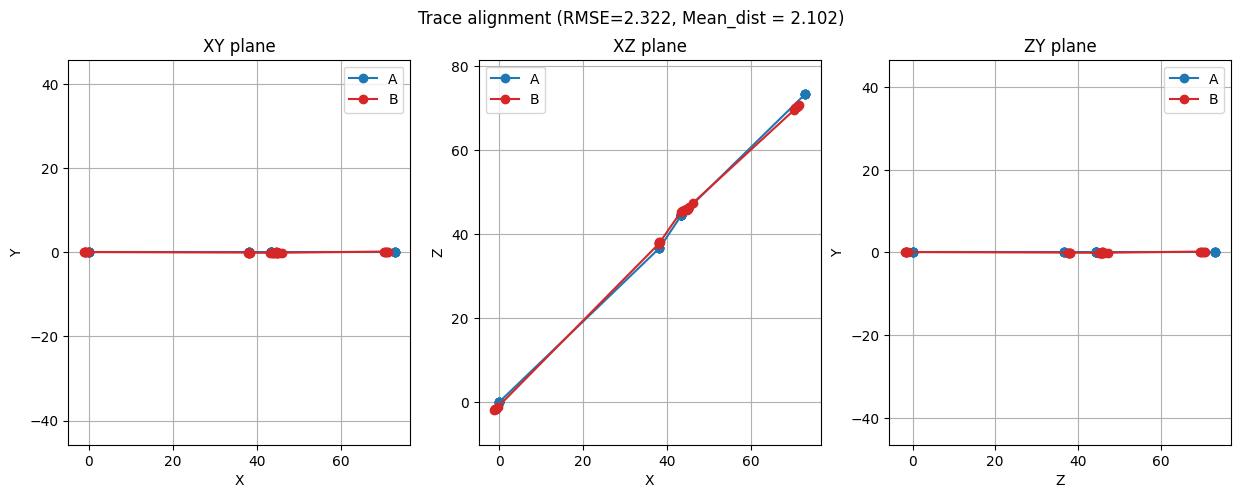

In [ ]:
#convert CAMERA POSES from RS model-world-space (set to CAM0) into real-world-space 
if flags["RECON_CAM_POSES"] == True and flags["VGGT_O_RECON"] ==True:
    
    #get lat lon positions
    #get transforms to convert other things too
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
    cam_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_gps(), csv_path_pose())
else:
    print("Cell disabled")


In [ ]:
#MULTI MERGE and PLY maker
if flags["MULTI_PART_RECON"] == True:
    
    from E_post_recon_processing import Reconstruction
    #Takes the lat and long to do mapping
    #Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
    if VGGT_O_RECON == True:
        if MULTI_PART_RECON == True:
            from B_VGGT_O_shards import discover_vggt_omega_shards
            from F_transforms_alignments import umeyama_align, recon_to_recon_transform, combine_transforms
            print("A")
            shards = discover_vggt_omega_shards(vggt_o_output_dir())
            print("B")
            #makes list of recons.
            recons = [
                Reconstruction.load(frames_for_recon_dir(), npz_path, FRAME_NAME_FMT, frame_range=(start, end))
                for start, end, npz_path in shards
            ]
            print(f"loaded {len(recons)} recon shards: {[(s, e) for s, e, _ in shards]}")
            multi = True
            #transforms to get separate recons to align with each other - save until all transforms are made
            print("merging")
            #get tranform needed to turn first recon from modelspace into real world
            R_mw , s_mw, t_mw  = recon_to_recon_transform(recons[0],cam_poses_realworld_dict)
            merge_xforms = [(R_mw , s_mw, t_mw)]
            
            #use overlapping frames to align the recon shards
            #start with the model to world
            R = R_mw
            s = s_mw
            t = t_mw
            #for poitn clouds: we don't want the real world
            Rpc = np.eye(3)
            spc = 1
            tpc = 0
            point_cloud_xforms = [(Rpc , spc, tpc)]
        
            for i in range(len(recons)):
                #for point cloud rendering
                #rotate, scale and transform the points into real-world space and then transform to the very first camera's position
                centre = recons[i].VGGT_O_preds_to_ply_export(vggt_o_output_dir()  / "ply" , R=R, t=t, s=s, multi=multi, centre_to_cam00=t_mw)
                #load up same frame's points from the 2 recons that overlap
                #now to prepare the transform for the next shard
                if i+1 <len(recons): 
                    #EXTRINSICS of the one that's already been done
                    #rotation+translation of final frame into model space when i =0, this is cam 0
                    extr = recons[i].preds["extrinsic"][-1].cpu().numpy()      #(3,4) model->cam matrix 
                    R_cm = extr[:3, :3].T                               #cam-to-model rotation 
                    t_cm= -R_cm @ extr[:3, 3]                   #cam to model translation

                    #extrinsics of the one to be done are all 00000, so we don't need it.
                    #but we do need scale: 
                    #  fx/fy ratios they won't match - since VGGT normalises
                    intr_to   = recons[i].preds["intrinsic"][-1].cpu().numpy()   
                    intr_from = recons[i+1].preds["intrinsic"][0].cpu().numpy()  
                    fx_ratio = intr_from[0, 0] / intr_to[0, 0]
                    fy_ratio = intr_from[1, 1] / intr_to[1, 1]
                    if abs(fx_ratio - fy_ratio) / min(fx_ratio, fy_ratio) > 0.05:
                        print(f"WARNING junction {i}->{i+1}: fx/fy scale ratios disagree by >5% "
                            f"(fx={fx_ratio:.4f}, fy={fy_ratio:.4f}) - inspect this shared frame")
                    s_cm = np.sqrt(fx_ratio * fy_ratio)   #geometric mean = least-squares combiner in log-space for a multiplicative factor
                
                    #then merge into 1 set of transforms
                    R,s,t = combine_transforms(R_cm, s_cm, t_cm, R, s, t) 
                    #point cloud transformers
                    Rpc, spc, tpc = combine_transforms(R_cm, s_cm, t_cm, Rpc, spc, tpc) 
                    merge_xforms.append((R,s,t))
                    point_cloud_xforms.append((Rpc, spc, tpc)) 


                    

In [ ]:
#MULTI SUBJECT ANALYSIS
if flags["MULTI_PART_RECON"] == True:
    from Q_subject_analysis import subject_to_metric_and_gps_space
    from F_transforms_alignments import merge_pos
    #transform all the positions into real world, separately -- same 3-way
    #unpack as the singular (MULTI_PART_RECON == False) path below, just once per shard
    sub_latlons, sub_poss, sub_pos_real_dicts = {}, {}, {}
    for i in range(len(recons)):
        sub_latlons[i], sub_poss[i], sub_pos_real_dicts[i] = subject_to_metric_and_gps_space(
            recons[i],
            masks_dir=str(yolo_masks_dir()),
            lat_0=lat_0, lon_0=lon_0,
            R_mw=merge_xforms[i][0], s_mw=merge_xforms[i][1], t_mw=merge_xforms[i][2],
        )

    #then combine each of the three across shards
    sub_latlon = [item for lst in sub_latlons.values() for item in lst]
    sub_pos = np.concatenate(list(sub_poss.values()))
    sub_pos_real_dict = merge_pos(*sub_pos_real_dicts.values())

In [ ]:
#LOAD VGGT_O recon for further processing
if flags["MULTI_PART_RECON"] == False:
    from Thr3D.F_post_recon_processing import Reconstruction
    recon = Reconstruction.load(frames_for_recon_dir(), predictions_path(), FRAME_NAME_FMT)
else:
    print("Cell Disabled")

Subject VGGT-O → real-world: 21 pairs, RMSE = 0.0512 m
[3854, 3860, 3866, 3872, 3878, 3884, 3890, 3893, 3902, 3908, 3914, 3920, 3924, 3932, 3938, 3944, 3950, 3956, 3962, 3968, 3974, 3980, 3986, 3992, 3998, 4004, 4010, 4016, 4022, 4028, 4034, 4040, 4046, 4052, 4058, 4064, 4070, 4076, 4082, 4088, 4094, 4100, 4106, 4112, 4118, 4124, 4130, 4136, 4142, 4148, 4154, 4160, 4166, 4172, 4178, 4184, 4190, 4196, 4202, 4208, 4214, 4220, 4226, 4232, 4238, 4244, 4250, 4256, 4262, 4268, 4274, 4280, 4286, 4292, 4298, 4304, 4310, 4316, 4322, 4328, 4334, 4337, 4343, 4349, 4358, 4361, 4373, 4379, 4382, 4388, 4394, 4397]
/workspaces/knuckles_drive/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_agent_temp/predictions.npz


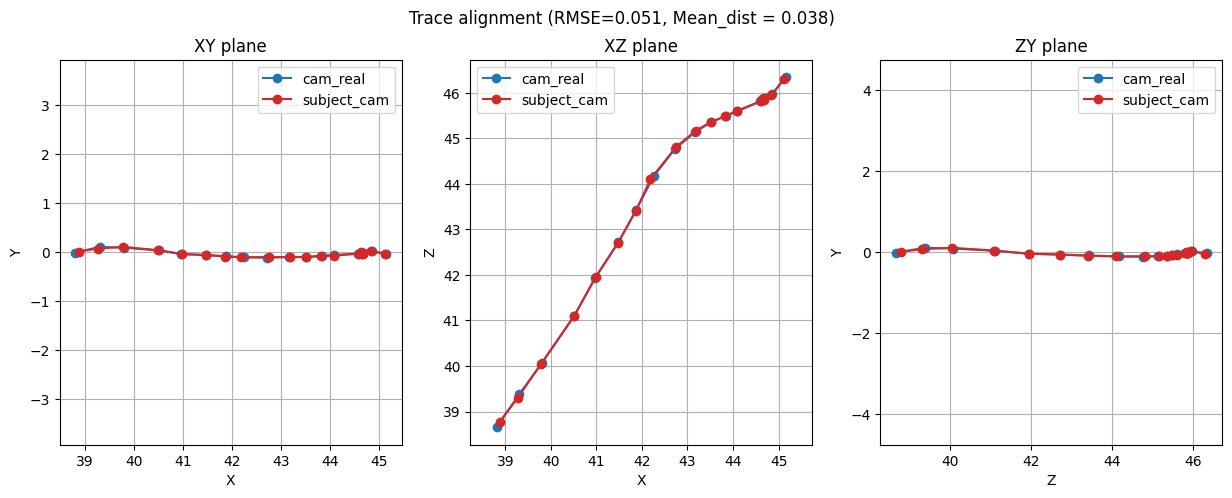

In [ ]:
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
MULTI_PART_RECON = False
if flags["RECON_CAM_POSES"] == True and flags["VGGT_O_RECON"] ==True:
    if MULTI_PART_RECON == False:
        from Q_subject_analysis import subject_to_metric_and_gps_space
        from Thr3D.G_transforms_alignments import  recon_to_recon_transform
        R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)

        sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
            recon,
            masks_dir        = str(yolo_masks_dir()),
            lat_0=lat_0, lon_0=lon_0,
            R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
            )    

        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
       #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
        _ = recon.VGGT_O_preds_to_ply_export(vggt_o_output_dir()  / "ply" , R=R_mw, t=t_mw, s=s_mw)
        
        print(predictions_path())
    else:
        print("Cell disabled")
else:
     print("Cell disabled")

In [ ]:
# Cell — PLY visualisation
if flags["CUT3R_RECON"] == True and flags["RECON_3D"] == True:
        
    import importlib, sys
    sys.path.insert(0, str(project_root / "src"))

    import D_cut3r_vis; importlib.reload(D_cut3r_vis)
    from D_cut3r_vis import visualise_cut3r
    visualisation_dir = case_dir()   /  vggt_o_output_dir()
    #visualisation_dir = case_dir()   /  cut3r_output_dir()
    visualise_cut3r(visualisation_dir)


Found 92 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

subject moved 6.679762539165677 m
subject moved in a 205.05716821938583 direction


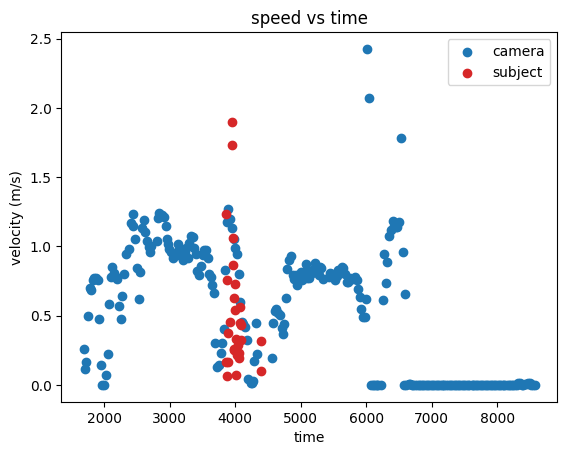

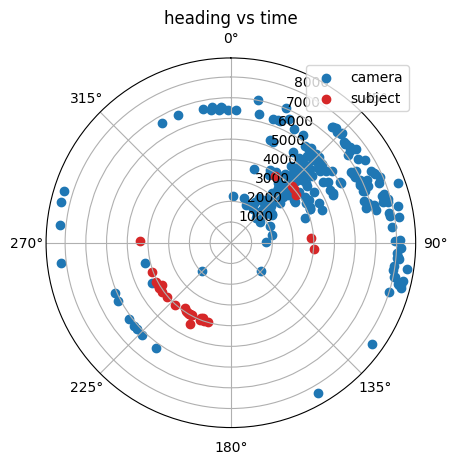

In [ ]:
##Graphing and analysis  
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import subject_reporting
fps = 30.07 #temp!
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction((cam_poses_realworld_dict,sub_pos_real_dict),
                                 fps,                                 
                                 )
subject_details =   subject_reporting(sub_pos_real_dict,cam_poses_realworld_dict,lat_0, lon_0 )



Text(0.5, 1.0, 'Subject position by shard (color = time)')

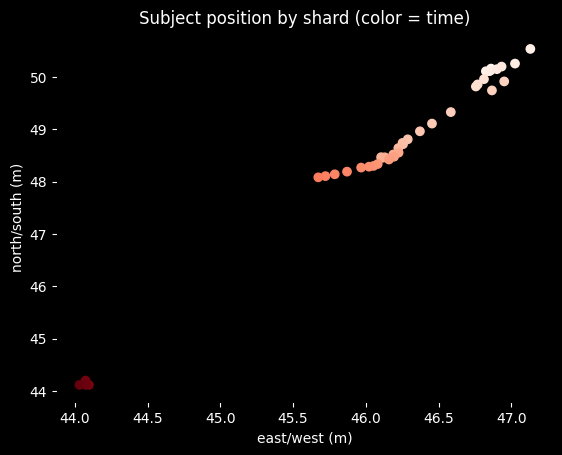

In [ ]:
#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)
frames_0 = np.array(sorted(sub_pos_real_dict))
pts = np.array([sub_pos_real_dict[k] for k in frames_0])
x_0 = pts[:, 0]
y_0 = pts[:, 2]

#y_0 = sub_pos_real_dict[1][:,2]
#x_0 = sub_pos_real_dict[1][:,0]
#y_1 = sub_rw_dicts[1][1][:,2]
#x_1 = sub_rw_dicts[1][1][:,0]
#y_2 = sub_rw_dicts[2][1][:,2]
#x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

sc = ax.scatter(x_0, y_0, c=frames_0, cmap="Reds")   # colour = frame number, not sample index
fig.colorbar(sc, ax=ax, label="frame")
#ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
#ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west (m)")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position by shard (color = time)")


In [ ]:
#make animated map -- always writes an image sequence to assets/map_frames
# (the standard hand-off to the editor); gif/mp4 below are optional extra
# exports of the same frames. Duration is read from the Producer's MAP beat
# inside R_map_animator.main() itself, not passed in here.
if flags["GOOGLE_MAP"] == True:
    import Rendering.R_map_animator

    R_map_animator.main(
        traces=[
            {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
            {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
        ],
        api_key     = api_key,
        gif = True,
        mp4 = None
        

    )
else:
    print("Cell disabled")

Auto-zoom: 19, centre (38.67586, 15.89581)
Fetching map...
  Fetching: https://maps.googleapis.com/maps/api/staticmap?center=38.67586296091851,15.89580...
Written: /workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/07_Tropea_cafe_cat_03_agent_temp_map.svg  (124 KB map, 183 KB SVG)
Rendering frames...
Written: /workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/map_frames  (180 frame PNGs)
Written: /workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/07_Tropea_cafe_cat_03_agent_temp_map.gif  (14316 KB GIF)


In [ ]:
#CAMERA TRANSFORMS - single recon at the moment
#1m up
ext = recon.preds["extrinsic"][9].clone()
ext[1, 3] += 1/16   # lift camera 1m (1/16 scale)

#10m up BEV
ext9 = recon.preds["extrinsic"][9]
Rx = torch.tensor([[1., 0., 0.],
                   [0., 0., -1.],
                   [0., 1., 0.]], dtype=ext9.dtype, device=ext9.device)

ext = Rx @ ext9        # pitch 90° down, camera stays where cam 9 was
ext[2, 3] += 20/16     # lift 10m (up is -z now that the view axis points down)
ext[1, 3] += 5/16      # forward 5m along cam 9's original heading

In [ ]:
if flags["PROJECTION_MAP"] == True:
    #2D projection mapping of subject to a selected view
    from E_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence
    from Two2D.B_video_processing import available_frames
    
    #Use this to project every frame in the recon
    extra_indices = available_frames(frames_for_recon_dir(), FRAME_NAME_FMT)
    print(extra_indices)
    
    
    if MULTI_PART_RECON == True:
      recon = recons
      point_cloud_xforms = point_cloud_xforms
    else: 
      recon = recon
      point_cloud_xforms = None
    subject_positions = projection_mapping_sequence(
        
        recon         = recon,
        main_idx      = 3908,
        extra_indices = range (3854,4397),
          #other syntax  [400,4027, 4052, 4065],
          #extra_indices = [extra_indices], - for composite (double [[]])
        masks_dir     = str(yolo_masks_dir()),
        point_cloud_xforms = point_cloud_xforms

        new_view = ext ,
        
        confidence_threshold = 2
       
       )
else:
    print("Cell disabled")

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
#render projection of 3D points clouds
from Rendering.U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if flags["VGGT_O_RECON"] ==True:
    visualisation_dir = case_dir()   /  vggt_o_output_dir() 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:

#cutr point cloud render
if flags["CUT3R_RECON"] ==True:  
    visualisation_dir = case_dir()   /  cut3r_output_dir() 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   



/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_CUT3R


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
#4D viewer
if flags["VGGT_O_RECON"] ==True:
     ply_dir = vggt_o_output_dir()  /"ply"  
from Rendering.U_rendering import view_ply_sequence_with_scenepic
FourD =  view_ply_sequence_with_scenepic(
    ply_dir , 
    point_size=0.01, 
    pattern="*.ply")

scenepic[info]> Disabling VideoWriter due to ImportError


In [ ]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)


FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/report_07_Tropea_cafe_cat_03.csv'

In [ ]:
if flags["MAKE_MOVIE"] ==True:
  #MAKING A MOVIE
  '''This controls M_scoring. It's independent of scene recon, so could be placed anywhere'''
  '''bring in M_scoring_controls'''
  from Two2D.W_video_editor import video_overlay_edit
  movie_start = movie_start
  moveie_end = movie_end
  movie =video_overlay_edit(video_path, 
                            movie_start, 
                            moveie_end, 
                            yolo_masks_dir(), 
                            3777, 4557,
                            handles=2, 
                          color=(0, 200, 0), 
                          alpha=0.4) 

NameError: name 'movie_start' is not defined

In [8]:
#find the cut points
if flags["MAKE_MOVIE_CUTS"] == True:
    import Two2D.W_video_editor
    W_video_editor.find_all_cut_points(video_path)

In [9]:
#run producer again
sys.path.insert(0, str(project_root / "src" / "claude_agent"))
from producer_agent_execution import run_producer_agent, build_producer_prompt_revision
analysis_2d_for_decisions=[]
prompt = build_producer_prompt_revision(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt)


[19:03:36 +  0.00s] run_producer_agent: start
[19:03:36 +  0.00s] thread: start
[19:03:36 +  0.00s] event loop: created
[19:03:36 +  0.01s] query: start


Ignoring 4 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspaces/knuckles_drive"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspaces/knuckles_drive"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


[19:04:32 + 56.44s] turn 1 usage (claude-sonnet-5): in=2 out=2 cache_write=10472 cache_read=9923
[19:05:03 + 87.62s] turn 2 usage (claude-sonnet-5): in=2 out=2 cache_write=10472 cache_read=9923
[19:05:03 + 87.62s] tool call: Write (/workspaces/knuckles_drive/Data/201_copper_01/012_agent_p_output/201_copper_01_paper_edit.json)
[19:05:12 + 96.78s] turn 3 usage (claude-sonnet-5): in=2 out=2 cache_write=7666 cache_read=20395
[19:05:12 + 96.85s] result: status=success num_turns=2 duration_ms=95713 duration_api_ms=98019 cost_usd=0.25032940000000004
[19:05:12 + 96.85s] result usage (aggregate): {'input_tokens': 4, 'cache_creation_input_tokens': 18138, 'cache_read_input_tokens': 30318, 'output_tokens': 8275, 'server_tool_use': {'web_search_requests': 0, 'web_fetch_requests': 0}, 'service_tier': 'standard', 'cache_creation': {'ephemeral_1h_input_tokens': 18138, 'ephemeral_5m_input_tokens': 0}, 'inference_geo': 'not_available', 'iterations': [{'input_tokens': 2, 'output_tokens': 629, 'cache_read

In [10]:
#Make the edited multimedia movie
if flags["MAKE_MOVIE_CUTS"] == True:
    import Two2D.W_video_editor
 
    W_video_editor.assemble_paper_edit(video_path)
else:
    print("Cell disabled")

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [ ]:
from V_text_summary import gemini_final_report, gemini_cache_video
from A_Config import assets_dir
video_path = assets_dir() / f"{asset_name}_overlay_video.mp4"
cache =  gemini_cache_video(video_path, assets_dir(), ttl="6000s")
gemini_final_report()

On May 30, 2026, at 11:40:31, a cat was captured on video wandering along a street in Tropea.

The cat, highlighted with a green tracking mask, is seen walking on the road near a parked black Volkswagen. It moves slowly along the street pavement, staying close to the curb and the front of the parked car.

A woman wearing a straw hat and a red sleeveless top walks past and observes the cat, while voices can be heard reacting to the feline's presence. This interaction and the cat's movement are documented from 11:40:31 to 11:40:49, spanning a duration of approximately 18.33 seconds.
**00:07** [Woman]: Guarda! Miao.

**00:10** [Woman]: No.

**00:12** [Woman]: No. No.

**00:17** [Woman]: Ma tu...

**00:21** [Woman]: No.


In [ ]:
# Cell — Populate PowerPoint from CSV
import sys
import importlib
sys.path.insert(0, str(project_root / "src"))

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir() / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir() / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))


  'Title' -> shape 'Title'
  'place' -> shape 'place'
  'overlay_mp4' -> shape 'overlay_mp4'
  'map_gif' -> shape 'map_gif'
  'speed_graph' -> shape 'speed_graph'
  'projection_mp4' -> shape 'projection_mp4'
  'point_cloud_render_VGGT_O_gif' -> shape 'point_cloud_render_VGGT_O_gif'
  'point_cloud_render_CUT3R_gif' -> shape 'point_cloud_render_CUT3R_gif'
  'transcript' -> shape 'transcript'
  'event_description' -> shape 'event_description'
  '4D_recon_clicker' -> shape '4D_recon_clicker'
  Removing empty slide (nothing matched from report)
  Removing empty slide (nothing matched from report)
  Removing empty slide (nothing matched from report)

Saved: /workspaces/knuckles_drive/Data/07_CAT_TEST/100_Powerpoint/07_CAT_TEST_v_01.pptx
